# NLP Project

In [22]:
import os
import pandas as pd

## Load Datasets

### Loading the results dataframe

---

**Dataframe Description**

This dataframe contains the results from the search for the most important features that I did in the *Visualizing Importance* section.

---


In [ ]:
import pandas as pd

# Load the file into a DataFrame
df_results = pd.read_csv("/kaggle/input/5-6-2025/results5-6.txt", sep="\t")

### Loading the training set

In [2]:
import pandas as pd

# Load the file into a DataFrame
df_pairs = pd.read_csv("/kaggle/input/5-6-2025/trainingSetFinal-5-6v2.txt", sep="\t")

In [ ]:
df_pairs.head()

### Loading the Test Set

In [5]:
import pandas as pd

# Load the file into a DataFrame
df_testPairs = pd.read_csv("/kaggle/input/5-6-2025/testSetFinal-5-6v2.txt", sep="\t")

In [ ]:
df_results.head()

### Loading the preprocessed-abstract set

In [ ]:
df_abstracts = pd.read_csv("/kaggle/input/25-5-2025/abstract_preprocessed2.txt", sep="\t")

In [ ]:
df_abstracts.head()

### Preparing The data

---

**Data Loading & Negative Example Creation**

This is the part where I load the initial dataframes and create the negative examples.

---


**Loading the abstracts DataFrame**

In [ ]:
abstracts = []
with open("/kaggle/input/citation-prediction-dataset/abstracts.txt", "r", encoding="utf-8") as file:
    for line in file:
        paper_id, abstract = line.strip().split("|--|")
        abstracts.append((int(paper_id), abstract))

df_abstracts = pd.DataFrame(abstracts, columns=["paper_id", "abstract"])

In [ ]:
df_abstracts.head()

**Loading the Authors DataFrame**

In [ ]:
authors = []
with open("/kaggle/input/citation-prediction-dataset/authors.txt", "r", encoding="utf-8") as file:
    for line in file:
        paper_id, author_list = line.strip().split("|--|")
        authors.append((int(paper_id), author_list.split(",")))

df_authors = pd.DataFrame(authors, columns=["paper_id", "authors"])

**Making the edges(connections between papers) DataFrame**

In [ ]:
edges = []
with open("/kaggle/input/citation-prediction-dataset/edgelist.txt", "r", encoding="utf-8") as file:
    for line in file:
        source, target = map(int, line.strip().split(","))
        edges.append((source, target))

df_edges = pd.DataFrame(edges, columns=["citing_paper", "cited_paper"])

In [ ]:
df_pairs = df_edges.copy

**Merging df_pairs with df_authors(if necessary, after adding the negative examples)**

In [ ]:
# Merge to get authors for the citing paper
df_merged = df_pairs.merge(df_authors, left_on="citing_paper", right_on="paper_id", how="left")
df_merged.rename(columns={"authors": "citing_authors"}, inplace=True)
df_merged.drop(columns=["paper_id"], inplace=True)  # 

# Merge to get authors for the cited paper
df_merged = df_merged.merge(df_authors, left_on="cited_paper", right_on="paper_id", how="left")
df_merged.rename(columns={"authors": "cited_authors"}, inplace=True)
df_merged.drop(columns=["paper_id"], inplace=True)  



In [ ]:
df_pairs.head()

**Adding extra (negative) samples**

In [ ]:
import random
import pandas as pd


existing_set = set(zip(df_pairs["citing_paper"], df_pairs["cited_paper"]))

paper_ids = df_abstracts["paper_id"].unique()


new_negative_samples = []
target_size = (1091955*2) - len(df_pairs)  

print("Generating additional negative samples...")

while len(new_negative_samples) < target_size:
    if len(new_negative_samples) % 50000 == 0:  
        print(f"Generated: {len(new_negative_samples)}")

    i, j = random.sample(list(paper_ids), 2)  # Pick two random papers

    if (i, j) not in existing_set and (j,i) not in existing_set and i != j :
        new_negative_samples.append((i, j))
        existing_set.add((i, j))  # adding to set to prevent future duplicates

# convert new negative samples to DataFrame
df_new_neg = pd.DataFrame(new_negative_samples, columns=["citing_paper", "cited_paper"])
df_new_neg["citation_label"] = 0  # Label as non-citations

# combine with existing df_pairs
df_pairs = pd.concat([df_pairs, df_new_neg], ignore_index=True)


In [ ]:
# Count NaN values in specific columns
nan_count_specific_columns = df_pairs[['citing_paper', 'cited_paper']].isna().sum()


print(nan_count_specific_columns)

In [ ]:
import pandas as pd


# extract all unique paper ids in training set
train_paper_ids = pd.unique(
    pd.concat([df_pairs['citing_paper'], df_pairs['cited_paper']])
)

# extract all unique paper ids in test set
test_paper_ids = pd.unique(
    pd.concat([df_testPairs['citing_paper'], df_testPairs['cited_paper']])
)

# filter abstracts for training papers
df_trainingabstracts = df_abstracts[df_abstracts['paper_id'].isin(train_paper_ids)].copy()

# filter abstracts for test papers
df_testabstracts = df_abstracts[df_abstracts['paper_id'].isin(test_paper_ids)].copy()

df_trainingabstracts.reset_index(drop=True, inplace=True)
df_testabstracts.reset_index(drop=True, inplace=True)


In [ ]:
df_trainingabstracts.head()

## Preprocessing

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
from nltk.stem import WordNetLemmatizer


In [ ]:
stop_words = set(stopwords.words('english'))

def preprocess_abstract(text):
    # lowercase
    text = str(text).lower()
    
    # remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # tokenize
    tokens = nltk.word_tokenize(text)
    
    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    
    return tokens


In [ ]:
df_abstracts['tokenized abstracts'] = df_abstracts['abstract'].apply(preprocess_abstract)

In [ ]:
df_abstracts.head()

In [ ]:
import ast

# convert string representations of lists into actual lists
df_abstracts['tokenized abstracts'] = df_abstracts['tokenized abstracts'].apply(ast.literal_eval)


---

**Analyzing the docs**

This is the part where I count how many words we have

---


In [ ]:
all_tokens = [token for token_list in df_abstracts['tokenized abstracts'] for token in token_list]
word_counts = Counter(all_tokens)


In [ ]:
top_common = word_counts.most_common(25)
print("Top 25 most common words:")
for word, count in top_common:
    print(f"{word}: {count}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

counts = np.array([count for word, count in word_counts.most_common()])
cumulative = np.cumsum(counts)
coverage = cumulative / cumulative[-1]  # divide by total

N = 25
plt.plot(range(1, len(coverage)+1), coverage)
plt.axvline(x=N, color='r', linestyle='--', label=f'Top {N}')
plt.axhline(y=coverage[N-1], color='g', linestyle='--', label=f'{coverage[N-1]*100:.2f}%')
plt.xlabel('Top N words')
plt.ylabel('Cumulative coverage of total tokens')
plt.title('Cumulative token coverage by top-N words')
plt.legend()
plt.grid(True)
plt.savefig('cumulative_coverage.png', dpi=300, bbox_inches='tight')
plt.show()


**Filtering out the 25 most common words**

In [ ]:

top_25_words = set([word for word, _ in word_counts.most_common(25)])
df_abstracts['filtered_tokens'] = df_abstracts['tokenized abstracts'].apply(lambda tokens: [w for w in tokens if w not in top_25_words])

In [ ]:
def join_tokens(token_list):
    return ' '.join(token_list)

df_abstracts['filtered_abstract'] = df_abstracts['filtered_tokens'].apply(join_tokens)

In [ ]:
df_abstracts.head()

In [ ]:
df_abstracts.rename(columns={'abstract': 'old_abstract', 'filtered_abstract': 'abstract'}, inplace=True)


### **A visual map of frequent words, where size indicates frequency.**

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()
#wc.to_file("wordCloud.png")

## Creating the Graph

In [ ]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()


for _, row in df_edges.iterrows():
    G.add_edge(row["citing_paper"], row["cited_paper"])

## Word2Vec

### Training set

In [ ]:
import gensim
from gensim.models import Word2Vec
import numpy as np


In [ ]:
df_trainingabstracts["filtered_tokens"] = df_trainingabstracts["filtered_tokens"].apply(gensim.utils.simple_preprocess)


In [ ]:
df_trainingabstracts.head()

In [ ]:
# setting up the model
word2vec_model = Word2Vec(sentences =df_trainingabstracts["filtered_tokens"] ,vector_size = 400,window=5, min_count=2, sg=1, epochs = 20)

In [ ]:
df_abstracts["filtered_tokens"] = df_abstracts["filtered_tokens"].apply(gensim.utils.simple_preprocess)


In [ ]:
def get_paper_embedding(abstract, model):
    words = abstract
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros((model.vector_size,))

df_abstracts["word2vec_embedding"] = df_abstracts["filtered_tokens"].apply(lambda x: get_paper_embedding(x, word2vec_model))


In [ ]:
df_abstracts["abstract"] = df_abstracts["abstract"].fillna("")
df_abstracts["has_abstract"] = df_abstracts["abstract"].apply(lambda x: 0 if x.strip() == "" else 1)


In [ ]:
word2vec_dict = dict(zip(df_abstracts['paper_id'], df_abstracts['word2vec_embedding']))
def get_avg_cited_word2vec(pid):
    if pid not in G:
        left_out_nodes.append(pid)
        return np.zeros(word2vec_dict[paper_id].shape)
    cited_neighbors = list(G.successors(pid)) + list(G.predecessors(pid))
    neighbor_word2vec = [word2vec_dict[n] for n in cited_neighbors if n in word2vec_dict]
    
    if not neighbor_word2vec:
        return np.zeros(word2vec_dict[paper_id].shape)

    return np.mean([vec for vec in neighbor_word2vec], axis=0)

# iterate and assign TF-IDF for papers with empty abstracts
imputed_word2vec = []
for _, row in df_abstracts.iterrows():
    if row["has_abstract"] == 0:
        pid = int(row["paper_id"])
        avg_word2vec = get_avg_cited_word2vec(pid)
        imputed_word2vec.append(avg_word2vec)
        if(avg_word2vec is not None):
            word2vec_dict[pid] = avg_word2vec

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# function to compute similarity between paper pairs
def compute_similarity(paper_i, paper_j):
    if paper_i in word2vec_dict and paper_j in word2vec_dict:
        return cosine_similarity([word2vec_dict[paper_i]], [word2vec_dict[paper_j]])[0][0]
    return 0  # Return 0 if any paper is missing

# apply to citation pairs
df_pairs["word2vec_similarity"] = df_pairs.apply(lambda row: compute_similarity(int(row["citing_paper"]), int(row["cited_paper"])), axis=1)


### Test set

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


# function to compute similarity between paper pairs
def compute_similarity(paper_i, paper_j):
    if paper_i in word2vec_dict and paper_j in word2vec_dict:
        return cosine_similarity([word2vec_dict[paper_i]], [word2vec_dict[paper_j]])[0][0]
    return 0  # Return 0 if any paper is missing

# apply to citation pairs
df_testPairs["word2vec_similarity"] = df_testPairs.apply(lambda row: compute_similarity(int(row["citing_paper"]), int(row["cited_paper"])), axis=1)


## TF-IDF

### Training set

- Calculating the textual similarity(with tf-idf)

In [ ]:
import numpy as np

In [ ]:
# clean abstract column and add has_abstract column 
df_trainingabstracts["abstract"] = df_trainingabstracts["abstract"].fillna("")
df_trainingabstracts["has_abstract"] = df_trainingabstracts["abstract"].apply(lambda x: 0 if x.strip() == "" else 1)

df_testabstracts["abstract"] = df_testabstracts["abstract"].fillna("")
df_testabstracts["has_abstract"] = df_testabstracts["abstract"].apply(lambda x: 0 if x.strip() == "" else 1)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# fit TF-IDF on abstracts
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_trainingabstracts["abstract"])

# create a dictionary for easy lookup
tfidf_dict = {paper_id: vec for paper_id, vec in zip(df_trainingabstracts["paper_id"], tfidf_matrix)}


In [ ]:
#for the test
tfidf_matrixTest= vectorizer.transform(df_testabstracts["abstract"])

# create a dictionary for easy lookup
tfidf_dictTest = {paper_id: vec for paper_id, vec in zip(df_testabstracts["paper_id"], tfidf_matrixTest)}


In [ ]:
full_tfidf_dict = tfidf_dict.copy()  # start with all keys from tfidf_dict

for key, value in tfidf_dictTest.items():
    if key not in full_tfidf_dict:
        full_tfidf_dict[key] = value


In [ ]:

def get_avg_cited_tfidf(pid):
    if pid not in G:
        return None
    cited_neighbors = list(G.successors(pid)) + list(G.predecessors(pid))
    neighbor_tfidfs = [full_tfidf_dict[n] for n in cited_neighbors if n in full_tfidf_dict]
    
    if not neighbor_tfidfs:
        return None
    return np.mean([vec.toarray() for vec in neighbor_tfidfs], axis=0)

# iterate and assign TF-IDF for papers with empty abstracts
imputed_tfidfs = []
for _, row in df_trainingabstracts.iterrows():
    if row["has_abstract"] == 0:
        pid = str(row["paper_id"])
        avg_tfidf = get_avg_cited_tfidf(int(pid))
        imputed_tfidfs.append(avg_tfidf)
        if(avg_tfidf is not None):
            full_tfidf_dict[pid] = avg_tfidf

imputed_tfidfs = []
for _, row in df_testabstracts.iterrows():
    if row["has_abstract"] == 0:
        pid = str(row["paper_id"])
        avg_tfidf = get_avg_cited_tfidf(int(pid))
        imputed_tfidfs.append(avg_tfidf)
        if(avg_tfidf is not None):
            full_tfidf_dict[pid] = avg_tfidf

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# compute pairwise cosine similarity
def compute_similarity(paper_i, paper_j):
    if paper_i in full_tfidf_dict and paper_j in full_tfidf_dict:
        return cosine_similarity(full_tfidf_dict[paper_i], full_tfidf_dict[paper_j])[0][0]
    return 0

df_pairs["textual_similarity"] = df_pairs.apply(lambda row: compute_similarity(row["citing_paper"], row["cited_paper"]), axis=1)


In [ ]:
df_pairs.head()

### Test set

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# compute pairwise cosine similarity
def compute_similarity(paper_i, paper_j):
    if paper_i in full_tfidf_dict and paper_j in full_tfidf_dict:
        return cosine_similarity(full_tfidf_dict[paper_i], full_tfidf_dict[paper_j])[0][0]
    return 0

df_testPairs["textual_similarity"] = df_testPairs.apply(lambda row: compute_similarity(row["citing_paper"], row["cited_paper"]), axis=1)


## Author overlap

### Training set

- Using the sorensen method

In [ ]:
import ast  # to safely convert string representation of lists into actual lists


def sorensen_dice_similarity(authors_i, authors_j):
    set_i = set(authors_i) if isinstance(authors_i, list) else set()
    set_j = set(authors_j) if isinstance(authors_j, list) else set()

    if not set_i or not set_j:  
        return 0.0
    
    intersection = len(set_i.intersection(set_j))
    return (2 * intersection) / (len(set_i) + len(set_j))

def safe_literal_eval(val):
    if isinstance(val, str):
        return ast.literal_eval(val)
    return val


df_merged = df_pairs.merge(
    df_authors, left_on='citing_paper', right_on='paper_id', how='left'
).rename(columns={'authors': 'citing_authors'}).drop(columns=['paper_id'])

df_merged = df_merged.merge(
    df_authors, left_on='cited_paper', right_on='paper_id', how='left'
).rename(columns={'authors': 'cited_authors'}).drop(columns=['paper_id'])

# Convert string lists into actual lists
df_merged["citing_authors"] = df_merged["citing_authors"].apply(safe_literal_eval)
df_merged["cited_authors"] = df_merged["cited_authors"].apply(safe_literal_eval)


df_pairs["author_overlap"] = df_merged.apply(
    lambda row: sorensen_dice_similarity(row["citing_authors"], row["cited_authors"]), axis=1
)


In [ ]:
df_pairs.head()

### Test set

In [ ]:
# merge to get authors for the citing paper
df_testMerged = df_testPairs.merge(
    df_authors, left_on='citing_paper', right_on='paper_id', how='left'
).rename(columns={'authors': 'citing_authors'}).drop(columns=['paper_id'])

df_testMerged = df_testMerged.merge(
    df_authors, left_on='cited_paper', right_on='paper_id', how='left'
).rename(columns={'authors': 'cited_authors'}).drop(columns=['paper_id'])

# Convert string lists into actual lists
df_testMerged["citing_authors"] = df_testMerged["citing_authors"].apply(safe_literal_eval)
df_testMerged["cited_authors"] = df_testMerged["cited_authors"].apply(safe_literal_eval)



In [ ]:
import ast  # to safely convert string representation of lists into actual lists

def sorensen_dice_similarity(authors_i, authors_j):
    set_i = set(authors_i) if isinstance(authors_i, list) else set()
    set_j = set(authors_j) if isinstance(authors_j, list) else set()

    if not set_i or not set_j:  # If any paper has no authors, return 0 similarity
        return 0.0
    
    intersection = len(set_i.intersection(set_j))
    return (2 * intersection) / (len(set_i) + len(set_j))

# convert string lists into actual lists
df_testPairs["citing_authors"] = df_testPairs["citing_authors"].apply(ast.literal_eval)
df_testPairs["cited_authors"] = df_testPairs["cited_authors"].apply(ast.literal_eval)

df_testPairs["author_overlap"] = df_merged.apply(
    lambda row: sorensen_dice_similarity(row["citing_authors"], row["cited_authors"]), axis=1
)


## Saving the training dataset

In [ ]:
df_abstracts.to_csv("abstract_preprocessed3.txt",sep="\t",index=False)

In [24]:
df_pairs[['citing_paper','cited_paper','citation_label']].to_csv("trainingSetFinal.txt", sep="\t", index=False)

In [ ]:
df_pairs.head()

## DOC2VEC

### Training set

In [ ]:
df_abstracts.head()

In [ ]:
import gensim
from gensim.models import Doc2Vec
import pandas as pd

#creating TaggedDocument for each paper
documents = [gensim.models.doc2vec.TaggedDocument(words= row['filtered_tokens'], tags=[str(row['paper_id'])]) for _, row in df_trainingabstracts.iterrows()]

In [ ]:
# Train the Doc2Vec model
doc2vecModel = Doc2Vec(vector_size = 400,window = 10, min_count = 2, epochs = 20)

In [ ]:
doc2vecModel.build_vocab(documents)
doc2vecModel.train(documents, total_examples = doc2vecModel.corpus_count, epochs = doc2vecModel.epochs)

In [ ]:
doc2vec_dict = {}
training_ids = set(df_trainingabstracts["paper_id"])


# iterate to compute Doc2Vec for each paper
for _, row in df_abstracts.iterrows():
    paper_id = row['paper_id']
    abstract = row['filtered_tokens'] 
    
    if paper_id in training_ids:
        embedding = doc2vecModel.dv[paper_id]
    else:
        embedding = doc2vecModel.infer_vector(abstract)
    
    # store in the dictionary
    doc2vec_dict[paper_id] = embedding

In [ ]:
#add the embeddings to df_combined,
df_abstracts['doc2vec_embedding'] = df_abstracts['paper_id'].map(doc2vec_dict)

In [ ]:
df_abstracts["has_abstract"] = df_abstracts["abstract"].apply(lambda x: 0 if x.strip() == "" else 1)

missing_abstracts = df_abstracts[df_abstracts["has_abstract"] == 0]

for paper_id in missing_abstracts["paper_id"]:
    neighbors = list(G.predecessors(paper_id)) + list(G.successors(paper_id))  # incoming + outgoing
    neighbor_embeddings = [doc2vec_dict[n] for n in neighbors if n in doc2vec_dict]

    if neighbor_embeddings:
        avg_embedding = np.mean(neighbor_embeddings, axis=0)
    else:
        example_embedding = next(iter(doc2vec_dict.values()))
        avg_embedding = np.zeros(doc2vec_dict[paper_id].shape)

    doc2vec_dict[paper_id] = avg_embedding

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# compute cosine similarity
def compute_similarity_doc2vec(paper_i, paper_j):
    if paper_i in doc2vec_dict and paper_j in doc2vec_dict:
        vec_i = np.array(doc2vec_dict[paper_i]).reshape(1, -1)
        vec_j = np.array(doc2vec_dict[paper_j]).reshape(1, -1)
        return cosine_similarity(vec_i,vec_j)[0][0]
    return 0

df_pairs["doc2vec_similarity"] = df_pairs.apply(lambda row: compute_similarity_doc2vec(row["citing_paper"], row["cited_paper"]), axis=1)


### Test set

In [ ]:

# compute cosine similarity
def compute_similarity_doc2vec(paper_i, paper_j):
    if paper_i in doc2vec_dict and paper_j in doc2vec_dict:
        return cosine_similarity(doc2vec_dict[paper_i].reshape(1,-1), doc2vec_dict[paper_j].reshape(1,-1))[0][0]

    return 0

df_testPairs["doc2vec_similarity"] = df_testPairs.apply(lambda row: compute_similarity_doc2vec(row["citing_paper"], row["cited_paper"]), axis=1)


## Implementing the graph

### Training set

In [ ]:
import networkx as nx

# create a directed graph
G = nx.DiGraph()

# add edges from the citation network
for _, row in df_edges.iterrows():
    G.add_edge(row["citing_paper"], row["cited_paper"])


In [ ]:
df_pairs["in_degree_j"] = df_pairs["cited_paper"].apply(lambda j: G.in_degree(j)) # Number of papers citing paper j
df_pairs["out_degree_i"] = df_pairs["citing_paper"].apply(lambda i: G.out_degree(i)) #Number of papers cited by paper i


In [ ]:
pagerank_scores = nx.pagerank(G)

df_pairs["pagerank_i"] = df_pairs["citing_paper"].map(pagerank_scores)
df_pairs["pagerank_j"] = df_pairs["cited_paper"].map(pagerank_scores)


---

**Common Citation Calculation**

This is the part where I calculate the common papers that *i* cites and that *j* cites.

---


In [ ]:
def jaccard_similarity(i, j):
    neighbors_i = set(G.predecessors(i))  # Papers citing i
    neighbors_j = set(G.predecessors(j))  # Papers citing j
    if not neighbors_i or not neighbors_j:
        return 0
    return len(neighbors_i & neighbors_j) / len(neighbors_i | neighbors_j)

df_pairs["jaccard_similarity"] = df_pairs.apply(lambda row: jaccard_similarity(row["citing_paper"], row["cited_paper"]), axis=1)


---

**Common Citation Calculation**

This is the part where I calculate the common papers that *i* cites and the ones that are citing *j*.

---


In [ ]:
def jaccard_similarity(i, j):
    neighbors_i = set(G.successors(i))  # Papers i cites
    neighbors_j = set(G.predecessors(j))  # Papers citing j
    if not neighbors_i or not neighbors_j:
        return 0
    return len(neighbors_i & neighbors_j) / len(neighbors_i | neighbors_j)

df_pairs["jaccard_similarity_suc_pre"] = df_pairs.apply(lambda row: jaccard_similarity(row["citing_paper"], row["cited_paper"]), axis=1)

### Test set

In [ ]:
df_testPairs["in_degree_j"] = df_testPairs["cited_paper"].apply(lambda j: G.in_degree(j)) # Number of papers citing paper j
df_testPairs["out_degree_i"] = df_testPairs["citing_paper"].apply(lambda i: G.out_degree(i)) #Number of papers cited by paper i

In [ ]:
pagerank_scores = nx.pagerank(G)

df_testPairs["pagerank_i"] = df_testPairs["citing_paper"].map(pagerank_scores)
df_testPairs["pagerank_j"] = df_testPairs["cited_paper"].map(pagerank_scores)

---

**Common Citation Calculation**

This is the part where I calculate the common papers that *i* cites and that *j* cites.

---


In [ ]:
def jaccard_similarity(i, j):
    neighbors_i = set(G.predecessors(i))  # Papers citing i
    neighbors_j = set(G.predecessors(j))  # Papers citing j
    if not neighbors_i or not neighbors_j:
        return 0
    return len(neighbors_i & neighbors_j) / len(neighbors_i | neighbors_j)

df_testPairs["jaccard_similarity"] = df_testPairs.apply(lambda row: jaccard_similarity(row["citing_paper"], row["cited_paper"]), axis=1)

---

**Common Citation Calculation**

This is the part where I calculate the common papers that *i* cites and the ones that are citing *j*.

---


In [ ]:
def jaccard_similarity(i, j):
    neighbors_i = set(G.successors(i))  # Papers i cites
    neighbors_j = set(G.predecessors(j))  # Papers citing j
    if not neighbors_i or not neighbors_j:
        return 0
    return len(neighbors_i & neighbors_j) / len(neighbors_i | neighbors_j)

df_testPairs["jaccard_similarity_suc_pre"] = df_testPairs.apply(lambda row: jaccard_similarity(row["citing_paper"], row["cited_paper"]), axis=1)

## NODE2VEC

### Training set

In [ ]:
import networkx as nx
from node2vec import Node2Vec
from gensim.models import Word2Vec
import pandas as pd


In [ ]:
import networkx as nx

# create a directed graph
G = nx.DiGraph()

# add edges from the citation network
for _, row in df_edges.iterrows():
    G.add_edge(row["citing_paper"], row["cited_paper"])


In [ ]:
# initialize Node2Vec model
node2vec = Node2Vec(G, dimensions = 512, walk_length=30, num_walks=100,workers=3)

In [ ]:
# train the node2cec model
node2vec_model = node2vec.fit(window=10, min_count=2,batch_words=4)

In [ ]:
# compute document similarity
def compute_node2vec_similarity(paper_i, paper_j):
    
    return node2vec_model.wv.similarity(int(paper_i), int(paper_j))

df_pairs["node2vec_similarity"] = df_pairs.apply(lambda row: compute_node2vec_similarity(row["citing_paper"], row["cited_paper"]),axis= 1)

In [ ]:
df_pairs.head()


### Test set

In [ ]:
#  compute document similarity
def compute_node2vec_similarity(paper_i, paper_j):
    
    return node2vec_model.wv.similarity(int(paper_i), int(paper_j))

df_testPairs["node2vec_similarity"] = df_pairs.apply(lambda row: compute_node2vec_similarity(row["citing_paper"], row["cited_paper"]),axis= 1)

## Hits Metric

In [ ]:
import networkx as nx
import pandas as pd

G = nx.DiGraph()

# add edges from the citation network
for _, row in df_edges.iterrows():
    G.add_edge(row["citing_paper"], row["cited_paper"])

In [ ]:
hub_scores, authority_scores = nx.hits(G, max_iter=200, normalized=True)


**Training Set**

In [ ]:

df_pairs['authority_citing'] = df_pairs['citing_paper'].map(authority_scores)
df_pairs['authority_cited'] = df_pairs['cited_paper'].map(authority_scores)
df_pairs['hub_citing'] = df_pairs['citing_paper'].map(hub_scores)
df_pairs['hub_cited'] = df_pairs['cited_paper'].map(hub_scores)

**Test set**

In [ ]:

df_testPairs['authority_citing'] = df_testPairs['citing_paper'].map(authority_scores)
df_testPairs['authority_cited'] = df_testPairs['cited_paper'].map(authority_scores)
df_testPairs['hub_citing'] = df_testPairs['citing_paper'].map(hub_scores)
df_testPairs['hub_cited'] = df_testPairs['cited_paper'].map(hub_scores)

## KATZ

### Training set

In [ ]:
import networkx as nx
import pandas as pd

G = nx.DiGraph()

# add edges from the citation network
for _, row in df_edges.iterrows():
    G.add_edge(row["citing_paper"], row["cited_paper"])



In [ ]:
# compute Katz centrality
katz_centrality = nx.katz_centrality(G)

In [ ]:
katz_df = pd.DataFrame({
    'paper_id': list(katz_centrality.keys()),
    'katz_centrality': list(katz_centrality.values())
})


In [ ]:
katz_df.head()

In [ ]:
# merge for citing_paper
df_pairs = df_pairs.merge(katz_df, how='left', left_on='citing_paper', right_on='paper_id')
df_pairs = df_pairs.rename(columns={"katz_centrality": "citing_katz"})
df_pairs = df_pairs.drop(columns=["paper_id"])  # drop redundant column

#  merge for cited_paper
df_pairs = df_pairs.merge(katz_df, how='left', left_on='cited_paper', right_on='paper_id')
df_pairs = df_pairs.rename(columns={"katz_centrality": "cited_katz"})
df_pairs = df_pairs.drop(columns=["paper_id"])


### Test set

In [ ]:
#  merge katz for citing_paper
df_testPairs = df_testPairs.merge(katz_df, how='left', left_on='citing_paper', right_on='paper_id')
df_testPairs = df_testPairs.rename(columns={"katz_centrality": "citing_katz"})
df_testPairs = df_testPairs.drop(columns=["paper_id"])  # drop redundant column

#  merge katz for cited_paper
df_testPairs = df_testPairs.merge(katz_df, how='left', left_on='cited_paper', right_on='paper_id')
df_testPairs = df_testPairs.rename(columns={"katz_centrality": "cited_katz"})
df_testPairs = df_testPairs.drop(columns=["paper_id"])


## EigenVector Centrality

### Training set

In [ ]:
import networkx as nx
import pandas as pd

G = nx.DiGraph()

# add edges from the citation network
for _, row in df_edges.iterrows():
    G.add_edge(row["citing_paper"], row["cited_paper"])



In [ ]:
# applying eigen vector centrality
eigenVector_centrality = nx.eigenvector_centrality(G,max_iter= 500)

In [ ]:
eigenVector_df = pd.DataFrame({
    'paper_id': list(eigenVector_centrality.keys()),
    'eigenVector_centrality': list(eigenVector_centrality.values())
})


In [ ]:
#  merge eigenVector for citing_paper
df_pairs = df_pairs.merge(eigenVector_df, how='left', left_on='citing_paper', right_on='paper_id')
df_pairs = df_pairs.rename(columns={"eigenVector_centrality": "citing_eigenVector"})
df_pairs = df_pairs.drop(columns=["paper_id"])  # drop redundant column

# merge eigenVector for cited_paper
df_pairs = df_pairs.merge(eigenVector_df, how='left', left_on='cited_paper', right_on='paper_id')
df_pairs = df_pairs.rename(columns={"eigenVector_centrality": "cited_eigenVector"})
df_pairs = df_pairs.drop(columns=["paper_id"])


In [ ]:
df_pairs.head()

### Test set

In [ ]:
# merge eigenVector for citing_paper
df_testPairs = df_testPairs.merge(eigenVector_df, how='left', left_on='citing_paper', right_on='paper_id')
df_testPairs = df_testPairs.rename(columns={"eigenVector_centrality": "citing_eigenVector"})
df_testPairs = df_testPairs.drop(columns=["paper_id"])  # drop redundant column

# merge eigenVector for cited_paper
df_testPairs = df_testPairs.merge(eigenVector_df, how='left', left_on='cited_paper', right_on='paper_id')
df_testPairs = df_testPairs.rename(columns={"eigenVector_centrality": "cited_eigenVector"})
df_testPairs = df_testPairs.drop(columns=["paper_id"])

## Sentence Transformer (SPECTER2)

### Training set

In [ ]:
import torch
import pandas as pd
from sentence_transformers import SentenceTransformer,util
import itertools

In [ ]:

model = SentenceTransformer('sentence-transformers/allenai-specter')

In [ ]:
df_abstracts['abstract'] = df_abstracts['abstract'].fillna('')
abstracts = df_abstracts['abstract'].tolist()

In [ ]:
# encode abstracts
embeddings = model.encode(abstracts, convert_to_tensor=True)

# convert embeddings to a list of NumPy arrays
df_abstracts["specter_embedding"] = [emb.cpu().numpy() for emb in embeddings]


embedding_dict = dict(zip(df_abstracts["paper_id"], embeddings))

In [ ]:
# clean abstract column and add has_abstract column
df_abstracts["abstract"] = df_abstracts["abstract"].fillna("")
df_abstracts["has_abstract"] = df_abstracts["abstract"].apply(lambda x: 0 if x.strip() == "" else 1)


In [ ]:

missing_abstracts = df_abstracts[df_abstracts["has_abstract"] == 0]

for paper_id in missing_abstracts["paper_id"]:
    neighbors = list(G.predecessors(paper_id)) + list(G.successors(paper_id))  # incoming + outgoing
    neighbor_embeddings = [embedding_dict[n] for n in neighbors if n in embedding_dict]

    if neighbor_embeddings:
        avg_embedding = torch.stack(neighbor_embeddings).mean(dim=0)
    else:
        example_embedding = next(iter(embedding_dict.values()))
        avg_embedding = torch.zeros_like(example_embedding)

    # Save the new embedding
    embedding_dict[paper_id] = avg_embedding

In [ ]:
import torch
from sentence_transformers import util

# move all embeddings to GPU once 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


for paper_id in embedding_dict:
    embedding_dict[paper_id] = embedding_dict[paper_id].to(device)

# compute pairwise cosine similarity
def compute_similarity(paper_i, paper_j):
    if paper_i in embedding_dict and paper_j in embedding_dict:
        # Get the embeddings on the same device (GPU or CPU)
        emb_i = embedding_dict[paper_i]
        emb_j = embedding_dict[paper_j]
        
        # Compute cosine similarity using PyTorch tensors 
        cos_sim = util.pytorch_cos_sim(emb_i, emb_j)
        
        return cos_sim.cpu().item()
    

    return 0


df_pairs["sent_transf_sim"] = df_pairs.apply(
    lambda row: compute_similarity(row["citing_paper"], row["cited_paper"]),
    axis=1
)


### Test set

In [ ]:

def compute_similarity(paper_i, paper_j):
    if paper_i in embedding_dict and paper_j in embedding_dict:
        # get the embeddings on the same device
        emb_i = embedding_dict[paper_i]
        emb_j = embedding_dict[paper_j]
        
        # compute cosine similarity using PyTorch tensors
        cos_sim = util.pytorch_cos_sim(emb_i, emb_j)
        
        # return similarity as a Python float (move to CPU before .item())
        return cos_sim.cpu().item()

    return 0

# apply the similarity function to the DataFrame
df_testPairs["sent_transf_sim"] = df_testPairs.apply(
    lambda row: compute_similarity(row["citing_paper"], row["cited_paper"]),
    axis=1
)
print("Missing Abstracts",counter)

In [ ]:
df_pairs.head()

## Visualizing Importance

In [ ]:
df_pairs.head()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

features = df_pairs.drop(columns=['citation_label', 'citing_paper', 'cited_paper'])
target = df_pairs['citation_label']

feature_names = features.columns
X = features.values
y = target.values

# calculate MI for each single feature once
mi_single = mutual_info_classif(X, y, discrete_features=False)

results = []

for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        f1 = feature_names[i]
        f2 = feature_names[j]
        
        mi1 = mi_single[i]
        mi2 = mi_single[j]
        
        # interaction term
        interaction = features[f1] * features[f2]
        
        mi_interaction = mutual_info_classif(interaction.values.reshape(-1, 1), y, discrete_features=False)[0]
        
        results.append({
            'feature1': f1,
            'feature2': f2,
            'mi1': mi1,
            'mi2': mi2,
            'mi_interaction': mi_interaction,
            'interaction_gain': mi_interaction - max(mi1, mi2)
        })

df_results = pd.DataFrame(results)


In [ ]:
df_results.head()

In [ ]:
# sort by interaction gain
df_results_sorted = df_results.sort_values('interaction_gain', ascending=False)
print("Top 10 interaction meta-features by MI gain:")
df_results_sorted[['feature1', 'feature2','mi1','mi2', 'mi_interaction', 'interaction_gain']].head(10)


In [ ]:
df_results.to_csv("results5-6.txt",sep="\t",index=False)

In [ ]:
print(df_results.shape)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sort unique features by MI
top_features = df_results.sort_values('mi1', ascending=False)

# keep only the top 20 unique feature1 
top20 = top_features.drop_duplicates(subset='feature1').head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='mi1', y='feature1', data=top20, palette='viridis')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.title('Top 20 Features by Mutual Information with Target')
plt.show()


In [ ]:
df_results_sorted[['feature1', 'feature2','mi1','mi2', 'mi_interaction', 'interaction_gain']].head(10)


**Creating the first two feature sets**

In [3]:
# Top 10 features
#top10_features
#all_features
#all_plus_meta_features
all_features = df_pairs.drop(columns=['citing_paper','cited_paper','citation_label'])
top10_features = df_pairs[['sent_transf_sim','textual_similarity','word2vec_similarity','out_degree_i','pagerank_i','citing_katz','hub_citing','authority_citing','jaccard_similarity_neighbors','jaccard_similarity_suc_pre']]

**Adding new Features based on interaction_gain**

In [6]:
df_pairs['text*outi'] = df_pairs['textual_similarity']*df_pairs['out_degree_i']
df_pairs['inj*outi'] = df_pairs['in_degree_j']*df_pairs['out_degree_i']
df_pairs['inj*doc'] = df_pairs['in_degree_j']*df_pairs['doc2vec_similarity']
df_pairs['outi*pageJ'] = df_pairs['out_degree_i']*df_pairs['pagerank_j']
df_pairs['outi*doc'] = df_pairs['out_degree_i']*df_pairs['doc2vec_similarity']
df_pairs['inj*hubciting'] = df_pairs['in_degree_j']*df_pairs['hub_citing']
df_pairs['word2vec*sentence'] = df_pairs['word2vec_similarity']*df_pairs['sent_transf_sim']
df_pairs['citingK*sentence'] = df_pairs['citing_katz']*df_pairs['sent_transf_sim']
df_pairs['word2vec*text'] = df_pairs['word2vec_similarity']*df_pairs['textual_similarity']
df_pairs['text*inj'] = df_pairs['textual_similarity']*df_pairs['in_degree_j']
df_pairs['outi*word2vec'] = df_pairs['out_degree_i']*df_pairs['word2vec_similarity']


df_testPairs['text*outi'] = df_testPairs['textual_similarity']*df_testPairs['out_degree_i']
df_testPairs['inj*outi'] = df_testPairs['in_degree_j']*df_testPairs['out_degree_i']
df_testPairs['inj*doc'] = df_testPairs['in_degree_j']*df_testPairs['doc2vec_similarity']
df_testPairs['outi*pageJ'] = df_testPairs['out_degree_i']*df_testPairs['pagerank_j']
df_testPairs['outi*doc'] = df_testPairs['out_degree_i']*df_testPairs['doc2vec_similarity']
df_testPairs['inj*hubciting'] = df_testPairs['in_degree_j']*df_testPairs['hub_citing']
df_testPairs['word2vec*sentence'] = df_testPairs['word2vec_similarity']*df_testPairs['sent_transf_sim']
df_testPairs['citingK*sentence'] = df_testPairs['citing_katz']*df_testPairs['sent_transf_sim']
df_testPairs['word2vec*text'] = df_testPairs['word2vec_similarity']*df_testPairs['textual_similarity']
df_testPairs['text*inj'] = df_testPairs['textual_similarity']*df_testPairs['in_degree_j']
df_testPairs['outi*word2vec'] = df_testPairs['out_degree_i']*df_testPairs['word2vec_similarity']


**Creating the third feature set** 

In [7]:
all_plus_meta_features = df_pairs.drop(columns=['citing_paper','cited_paper','citation_label'])

## GaussianNB

In [ ]:
df_pairs.head()

### Feature Selection

In [ ]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


features = df_pairs.drop(columns=['citing_paper', 'cited_paper', 'citation_label']).columns.tolist()

plots_per_figure = 4
num_features = len(features)

for i in range(0, num_features, plots_per_figure):
    feature_chunk = features[i:i + plots_per_figure]
    n = len(feature_chunk)
    
    n_cols = 2
    n_rows = math.ceil(n / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    else:
        axes = np.array(axes).reshape(-1)
    
    for j, feature in enumerate(feature_chunk):
        sns.histplot(data=df_pairs, x=feature, hue='citation_label', kde=True, bins=30, ax=axes[j])
        axes[j].set_title(f'Distribution of {feature} by Class')
    
    # hide any extra unused subplots
    for k in range(n, len(axes)):
        fig.delaxes(axes[k])
    
    plt.tight_layout()
    save_name = f"feature_plot_group_{i // plots_per_figure + 1}.png"
    plt.savefig(save_name)
    plt.show()


---

> 📌 **Note:** Here I am applying the Gaussian NB.

---


In [ ]:
df_pairs.head()

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import log_loss
from sklearn.preprocessing import MinMaxScaler
#top10_features
#all_features
#all_plus_meta_features
X = df_pairs[['node2vec_similarity','sent_transf_sim']]
y = df_pairs["citation_label"] 

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)

nb_modelGaussian = GaussianNB()


y_proba2 = cross_val_predict(nb_modelGaussian, X_train_scaled, y, cv=5, method='predict_proba') 
# compute log loss
log_loss_value = log_loss(y, y_proba2)

print(f"Model Log Loss: {log_loss_value:.5f}")

### Testing

In [ ]:
nb_modelGaussian.fit(X_train_scaled,y)

In [ ]:
X_test =  df_testPairs[['node2vec_similarity','sent_transf_sim']]
X_test_scaled = scaler.fit_transform(X_test)
y_probaGaussianNB = nb_modelGaussian.predict_proba(X_test_scaled)

### Saving the Results

In [ ]:
import numpy as np
y_pred = y_probaGaussianNB[:, 1] 


df_testResults = pd.DataFrame({
    "ID": range(len(y_pred)),  
    "Label": y_pred  
})

# save to CSV
df_testResults.to_csv("predictionsGaussianNB29-5v2.csv", index=False)


## Logistic Regression

In [ ]:
df_pairs.head()

### Feature Selection

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.model_selection import  cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss
#top10_features
#all_features
#all_plus_meta_features

# prepare X and y
X = df_pairs.drop(columns = ['citing_paper','cited_paper','citation_label'])
y = df_pairs["citation_label"]  # binary target


scalerLR = MinMaxScaler()
X_scaled = scalerLR.fit_transform(X) 


logreg = LogisticRegression(max_iter=1000)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


rfecv = RFECV(estimator=logreg,step=1,cv=cv,scoring='neg_log_loss', n_jobs=3)


rfecv.fit(X_scaled, y)

# results
print(f"Optimal number of features: {rfecv.n_features_}")
print("Selected features:", X.columns[rfecv.support_])

plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (log loss)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         -rfecv.cv_results_['mean_test_score'], marker='o')
plt.title("RFECV Feature Selection with Logistic Regression")
plt.show()


In [ ]:
-rfecv.cv_results_['mean_test_score']

In [ ]:
df_abstracts.head()

### Training

In [ ]:
# Top 10 features
#top10_features
#all_features
#all_plus_meta_features
['sent_transf_sim','textual_similarity','word2vec_similarity','out_degree_i','pagerank_i','citing_katz','hub_citing','authority_citing','jaccard_similarity_neighbors','jaccard_similarity_suc_pre']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import  cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss

X1 = df_pairs[all_plus_meta_features.columns]  # Features
y1 = df_pairs["citation_label"] 

scalerLR = MinMaxScaler()
X_scaled1 = scalerLR.fit_transform(X1) 
log_reg = LogisticRegression(max_iter=1000)

y_proba1 = cross_val_predict(log_reg, X_scaled1, y1, cv=5, method='predict_proba',n_jobs=3)

# compute Log Loss
log_loss_value = log_loss(y1, y_proba1)
print(f"Logistic Regression Log Loss (5-fold CV): {log_loss_value:.4f}")


### Testing

In [ ]:
log_reg.fit(X_scaled1, y1)

X_test1 = df_testPairs[all_plus_meta_features.columns]

X_test_scaled1 = scalerLR.transform(X_test1)

y_probatest1 = log_reg.predict_proba(X_test_scaled1)


In [ ]:
import numpy as np

y_pred = y_probatest1[:, 1]  


df_testResults = pd.DataFrame({
    "ID": range(len(y_pred)),  
    "Label": y_pred  
})

# save to CSV
df_testResults.to_csv("predictionsLR5-6v1.csv", index=False)


## SGD Classifier

### Feature Selection

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.model_selection import  cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss


X = df_pairs.drop(columns = ['citing_paper','cited_paper','citation_label'])
y = df_pairs["citation_label"]

sgdScaler = MinMaxScaler()
X_scaled = sgdScaler.fit_transform(X)

sgd_clf = SGDClassifier(loss="log_loss")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


rfecv = RFECV(estimator=sgd_clf,step=1,cv=cv,scoring='neg_log_loss', n_jobs=3)


rfecv.fit(X_scaled, y)


print(f"Optimal number of features: {rfecv.n_features_}")
print("Selected features:", X.columns[rfecv.support_])

# plot
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (log loss)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         -rfecv.cv_results_['mean_test_score'], marker='o')
plt.title("RFECV Feature Selection with Logistic Regression")
plt.show()


### Training

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_predict

#top10_features
#all_features
#all_plus_meta_features

X = df_pairs[all_plus_meta_features.columns]  
y = df_pairs["citation_label"]  


sgdScaler = MinMaxScaler()
X_scaled = sgdScaler.fit_transform(X)

sgd_clf = SGDClassifier(loss="log_loss")
sgd_proba = cross_val_predict(sgd_clf, X_scaled, y, cv=5, method='predict_proba',n_jobs=3)

# compute Log Loss 
log_loss_value = log_loss(y, sgd_proba)
print(f"SGD Log Loss (5-fold CV): {log_loss_value:.5f}")



### Test

In [ ]:
sgd_clf.fit(X_scaled, y)

X_test = df_testPairs[all_plus_meta_features.columns]

X_test_scaled = sgdScaler.transform(X_test)

y_probatest = sgd_clf.predict_proba(X_test_scaled)


In [ ]:
import numpy as np

y_pred = y_probatest[:, 1]  


df_testResults = pd.DataFrame({
    "ID": range(len(y_pred)),  
    "Label": y_pred  
})

# save to csv
df_testResults.to_csv("predictionsSGD5-6v1.csv", index=False)


## Decision Tree

### Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import log_loss
from sklearn.preprocessing import MinMaxScaler

X = df_pairs[all_plus_meta_features.columns]  
y = df_pairs["citation_label"]  



dt_model = DecisionTreeClassifier(criterion="log_loss", max_depth=2, random_state=42)


y_proba_cv = cross_val_predict(dt_model, X, y, cv=5, method="predict_proba",n_jobs=3)

# compute log loss
log_loss_value = log_loss(y, y_proba_cv)
print(f"Cross-Validation Log Loss: {log_loss_value:.5f}")


### Testing

In [ ]:
dt_model.fit(X, y)

X_test = df_testPairs[all_plus_meta_features.columns]


y_probaTestDT = dt_model.predict_proba(X_test)

In [ ]:
import numpy as np

y_pred = y_probaTestDT[:, 1] 


df_testResults = pd.DataFrame({
    "ID": range(len(y_pred)),  
    "Label": y_pred  
})

# save to csv
df_testResults.to_csv("predictionsDT5-6v1.csv", index=False)


## Random Forest

### Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import log_loss
#top10_features
#all_features
#all_plus_meta_features
X = df_pairs[all_plus_meta_features.columns]  
y = df_pairs["citation_label"]  


rf_model = RandomForestClassifier(criterion="log_loss", max_depth=4, random_state=42)


y_proba_rf = cross_val_predict(rf_model, X, y, cv=5, method="predict_proba",n_jobs=3)

# compute log loss
log_loss_value = log_loss(y, y_proba_rf)
print(f"Cross-Validation Log Loss: {log_loss_value:.5f}")


### Test

In [ ]:
rf_model.fit(X, y)

X_test = df_testPairs[all_plus_meta_features.columns]


y_probaTestRF = rf_model.predict_proba(X_test)

In [ ]:
import numpy as np

y_pred = y_probaTestRF[:, 1]  


df_testResults = pd.DataFrame({
    "ID": range(len(y_pred)), 
    "Label": y_pred  
})

# save to csv
df_testResults.to_csv("predictionsRF5-6v1.csv", index=False)


## k-NN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import log_loss

X = df_pairs[["textual_similarity", "author_overlap"]]  
y = df_pairs["citation_label"]


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


knn_model = KNeighborsClassifier(n_neighbors=5, metric='cosine',n_jobs=3)

y_proba_knn = cross_val_predict(knn_model, X_scaled, y, cv=5, method="predict_proba",n_jobs=3)

# compute log loss
log_loss_value = log_loss(y, y_proba_knn)
print(f"Cross-Validation Log Loss: {log_loss_value:.5f}")




## MLP

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import log_loss
from sklearn.preprocessing import MinMaxScaler


### Training

In [ ]:
df_pairs.head()

In [ ]:
#top10_features
#all_features
#all_plus_meta_features

In [ ]:
# define features 
X = df_pairs[all_plus_meta_features.columns]
y = df_pairs["citation_label"]

In [ ]:
# scale features
scaler_mlp = MinMaxScaler()
X_scaled = scaler_mlp.fit_transform(X)

mlp = MLPClassifier(hidden_layer_sizes=(16),
                    activation='relu',
                    solver='adam',
                   max_iter = 800)




y_proba = cross_val_predict(mlp, X_scaled, y, cv=5, method="predict_proba")

# evaluate using log loss
loss = log_loss(y, y_proba)
print(f"Cross-Validation Log Loss: {loss:.5f}")


In [ ]:
mlp.fit(X_scaled, y)

### Testing

In [ ]:
X_test =  df_testPairs[all_plus_meta_features.columns]
X_test_scaled = scaler_mlp.transform(X_test)

y_probatest = mlp.predict_proba(X_test_scaled)

In [ ]:
import numpy as np

y_pred = y_probatest[:, 1]



df_testResults = pd.DataFrame({
    "ID": range(len(y_pred)),  
    "Label": y_pred
})

# save to csv
df_testResults.to_csv("predictionsMLP6-6v5.csv", index=False)


## XGBOOST

In [8]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import log_loss

### Feature Selection

In [ ]:
df_pairs.head()

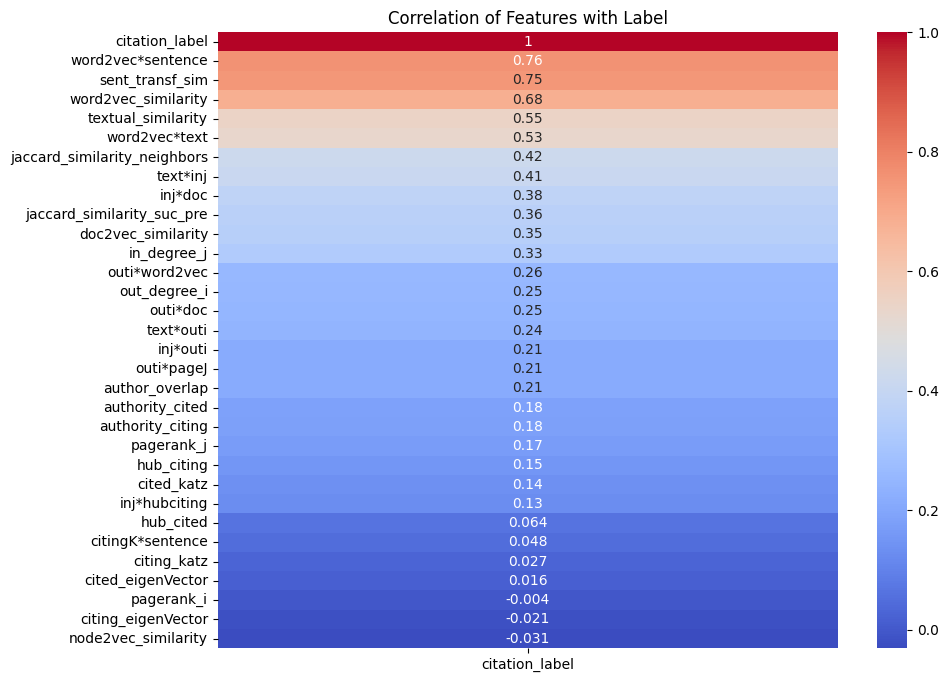

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_pairs.drop(columns=["citing_paper","cited_paper"]).corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr[['citation_label']].sort_values(by='citation_label', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation of Features with Label")
plt.show()


In [ ]:
df_pairs.head()

**checking correlation between pairs**

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


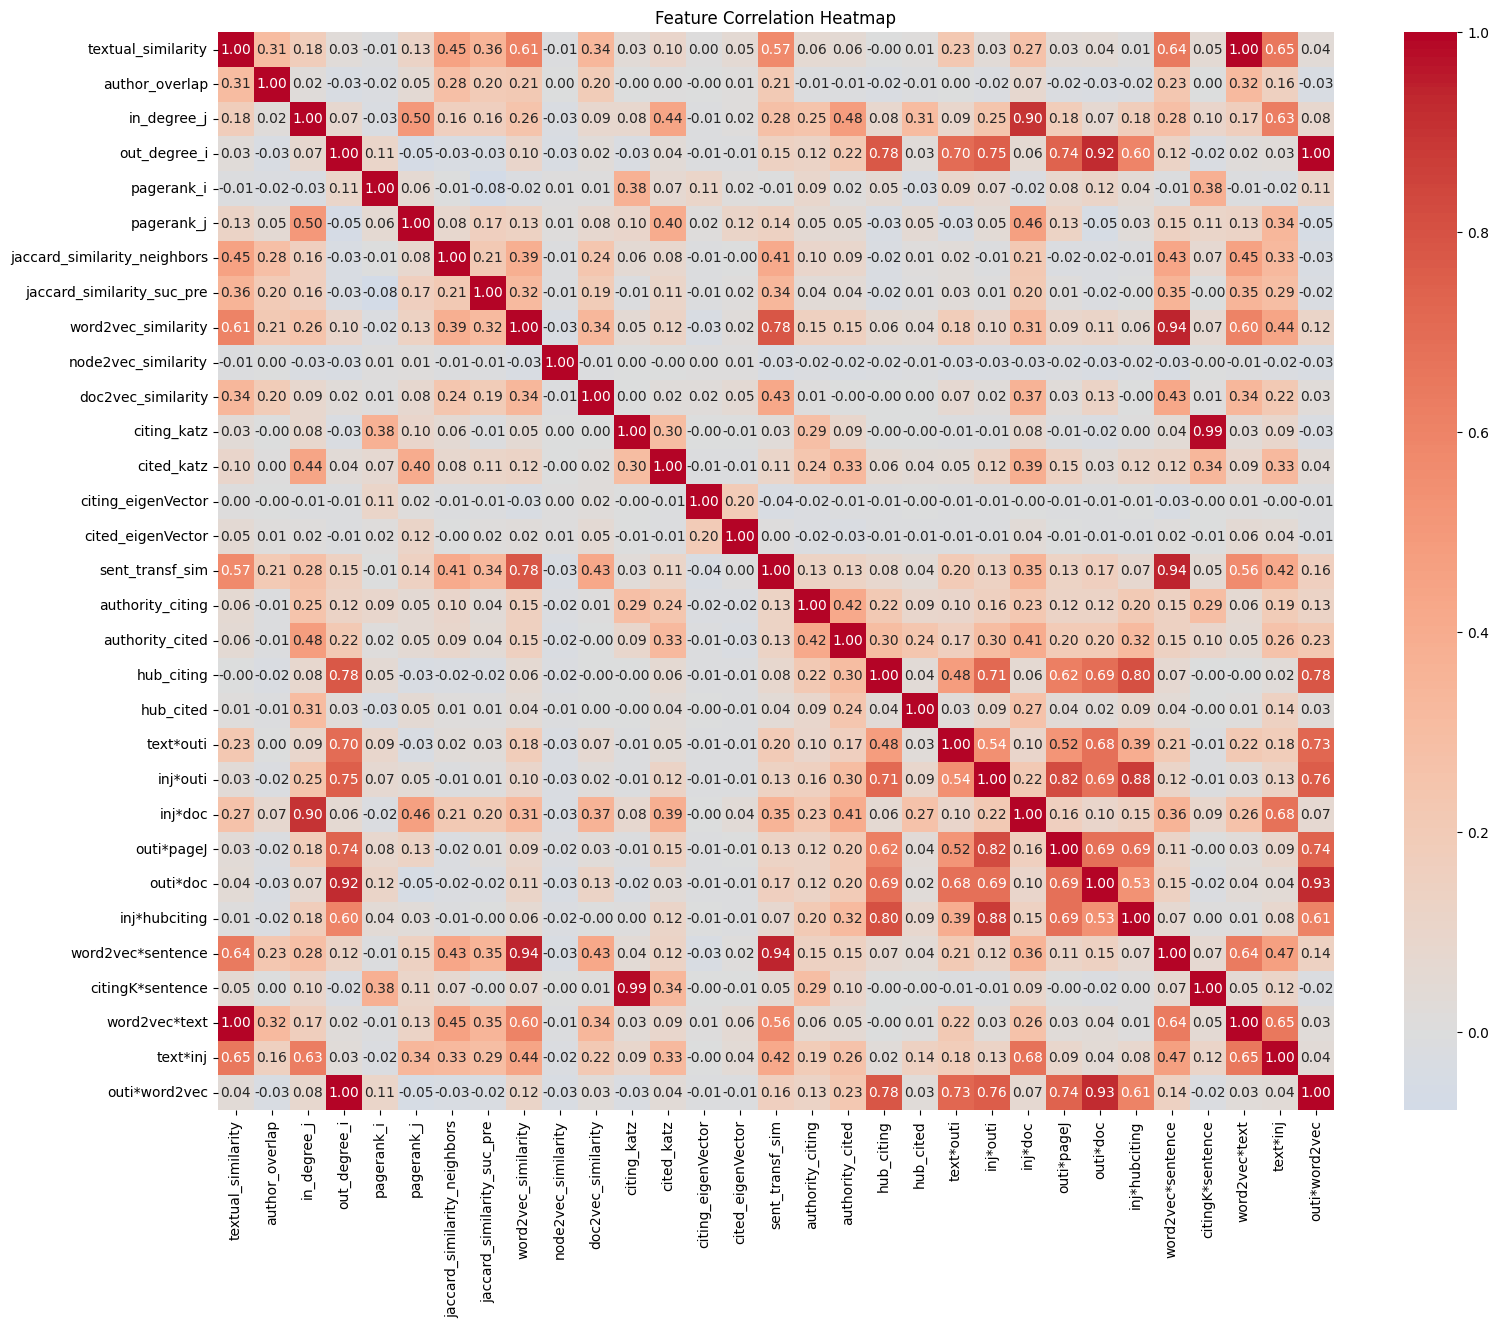

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


feature_cols = df_pairs.drop(columns=["citing_paper","cited_paper","citation_label"]).columns
corr_matrix = df_pairs[feature_cols].corr(method='pearson')
plt.figure(figsize=(18,14))#(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


### Training

In [ ]:
#top10_features
#all_features
#all_plus_meta_features

In [ ]:

X = df_pairs[all_features.columns]
y = df_pairs["citation_label"]
model_xgb = XGBClassifier(objective = 'binary:logistic',eval_metric='logloss',learning_rate=0.05,max_depth=2,n_estimators=400)




y_proba = cross_val_predict(model_xgb, X, y, cv=5, method="predict_proba")

# evaluate using log loss
loss = log_loss(y, y_proba)
print(f"Cross-Validation Log Loss: {loss:.5f}")

In [ ]:

model_xgb.fit(X,y)

### Testing

In [ ]:
X_test =  df_testPairs[all_features.columns]
y_probaxgboost = model_xgb.predict_proba(X_test)

### Saving Test Results

In [ ]:
import numpy as np

y_pred = y_probaxgboost[:, 1] 



df_testResults = pd.DataFrame({
    "ID": range(len(y_pred)),  
    "Label": y_pred  
})

# save to csv
df_testResults.to_csv("predictionsXgBoost5-6v1.csv", index=False)


## Saving The testSet

In [ ]:
df_testPairs.head()

In [26]:
df_testPairs[['citing_paper','cited_paper']].to_csv("testSetFinal.txt", sep="\t", index=False)